In [39]:
import pandas as pd
import numpy as np

NUMERIC_PATH = "/content/StressLevelDataset.csv"
SURVEY_PATH  = "/content/Stress_Dataset (1).csv"

numeric_df = pd.read_csv(NUMERIC_PATH)
survey_df  = pd.read_csv(SURVEY_PATH)

print("Numeric dataset shape:", numeric_df.shape)
print("Survey dataset shape: ", survey_df.shape)

Numeric dataset shape: (1100, 21)
Survey dataset shape:  (843, 26)


Dataset-> https://www.kaggle.com/datasets
My project one looks at student stress using data from one source that was organized into numeric, survey and text format. Using machine learning models to predict stress levels and see how results change based on the type of data. Logistic Regression, Decision trees, and random forests were used for the numeric and survey data, and TF-IDF with logistic regression was used for the text data. The results show that numeric data is easier to preidct, survey data can be misleading because most values fall into one group, and the text data is harder to classify.

In [40]:
display(numeric_df.head())
display(survey_df.head())

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,0,20,3,4,2,5,1,2,1,2,...,3,1,4,1,2,1,3,1,2,Eustress (Positive Stress) - Stress that motiv...
1,0,20,2,3,2,1,1,1,1,4,...,3,2,1,1,3,2,1,4,2,Eustress (Positive Stress) - Stress that motiv...
2,0,20,5,4,2,2,1,3,4,2,...,2,2,2,1,4,1,1,2,1,Eustress (Positive Stress) - Stress that motiv...
3,1,20,3,4,3,2,2,3,4,3,...,1,1,2,1,2,1,1,5,3,Eustress (Positive Stress) - Stress that motiv...
4,0,20,3,3,3,2,2,4,4,4,...,2,3,1,2,2,4,2,2,2,Eustress (Positive Stress) - Stress that motiv...


In [41]:
numeric_target_col = "stress_level"

#mapping numeric labels to text for interpretation
numeric_label_map = {0: "Low", 1: "Medium", 2: "High"}
numeric_df["stress_level_label"] = numeric_df[numeric_target_col].map(numeric_label_map)


X_numeric = numeric_df.drop(columns=[numeric_target_col, "stress_level_label"])
y_numeric = numeric_df[numeric_target_col]

print("Numeric target distribution (proportions):")
print(y_numeric.value_counts(normalize=True).sort_index())

Numeric target distribution (proportions):
stress_level
0    0.339091
1    0.325455
2    0.335455
Name: proportion, dtype: float64


In [42]:
survey_target_col = "Which type of stress do you primarily experience?"

def simplify_stress_label(text):
    if isinstance(text, str):
        if "Eustress" in text:
            return "Eustress"
        if "No Stress" in text:
            return "NoStress"
        if "Distress" in text:
            return "Distress"
    return "Other"

survey_df["stress_type_simple"] = survey_df[survey_target_col].apply(simplify_stress_label)

#only keeping 3 main categories
survey_df = survey_df[survey_df["stress_type_simple"].isin(["Eustress", "NoStress", "Distress"])].copy()

X_survey = survey_df.drop(columns=[survey_target_col, "stress_type_simple"])
y_survey = survey_df["stress_type_simple"]

print("Survey target distribution (proportions):")
print(y_survey.value_counts(normalize=True))

Survey target distribution (proportions):
stress_type_simple
Eustress    0.911032
NoStress    0.051008
Distress    0.037960
Name: proportion, dtype: float64


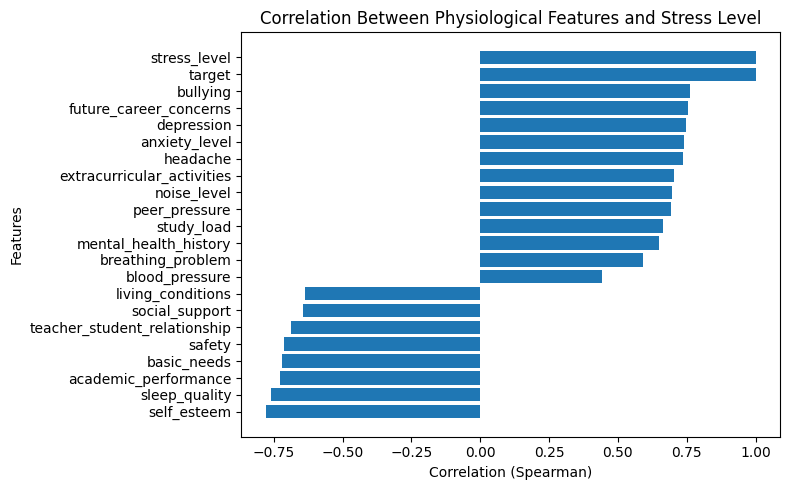

In [43]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

target_survey = "stress_level"

le = LabelEncoder()
numeric_df["target"] = le.fit_transform(numeric_df[target_survey].astype(str))

numeric_cols = numeric_df.select_dtypes(include=[np.number]).columns

correlations = (
    numeric_df[numeric_cols]
    .corrwith(numeric_df["target"], method="spearman")
    .sort_values(ascending=False)
)


plt.figure(figsize=(8, 5))
plt.barh(correlations.index, correlations.values)
plt.title("Correlation Between Physiological Features and Stress Level")
plt.xlabel("Correlation (Spearman)")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [44]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 340
TEST_SIZE = 0.2

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_numeric,
    y_numeric,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_numeric,
)

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_survey,
    y_survey,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_survey,
)

print("Numeric train/test shapes:", Xn_train.shape, Xn_test.shape)
print("Survey  train/test shapes:", Xs_train.shape, Xs_test.shape)

Numeric train/test shapes: (880, 20) (220, 20)
Survey  train/test shapes: (674, 25) (169, 25)


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

def make_models():
    models = {}

    #logistic regression
    models["LogisticRegression"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            multi_class="multinomial"
        )),
    ])

    #decision tree
    models["DecisionTree"] = DecisionTreeClassifier(
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )

    #random forest
    models["RandomForest"] = RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    return models

numeric_models = make_models()
survey_models  = make_models()

numeric_models, survey_models

({'LogisticRegression': Pipeline(steps=[('scaler', StandardScaler()),
                  ('clf',
                   LogisticRegression(class_weight='balanced', max_iter=1000,
                                      multi_class='multinomial'))]),
  'DecisionTree': DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=5,
                         random_state=340),
  'RandomForest': RandomForestClassifier(class_weight='balanced', min_samples_leaf=3,
                         n_estimators=200, n_jobs=-1, random_state=340)},
 {'LogisticRegression': Pipeline(steps=[('scaler', StandardScaler()),
                  ('clf',
                   LogisticRegression(class_weight='balanced', max_iter=1000,
                                      multi_class='multinomial'))]),
  'DecisionTree': DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=5,
                         random_state=340),
  'RandomForest': RandomForestClassifier(class_weight='balanced', min_samples_leaf=3,
        

In [46]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Fit model and return metrics + predictions + confusion matrix.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")
    cm  = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))

    return acc, f1, cm, y_pred, np.unique(y_test)


=== LogisticRegression (Numeric dataset) ===
Accuracy: 0.8545454545454545
F1 (macro): 0.854869833295273

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        74
           1       0.88      0.88      0.88        72
           2       0.82      0.85      0.83        74

    accuracy                           0.85       220
   macro avg       0.86      0.85      0.85       220
weighted avg       0.86      0.85      0.85       220



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


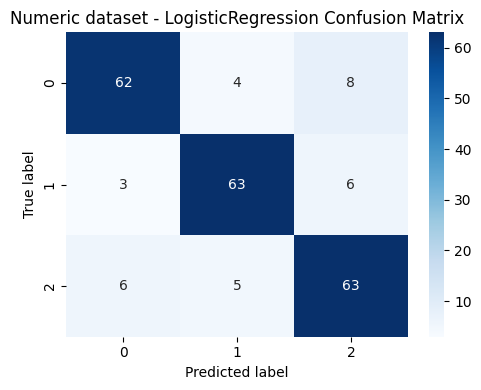


=== DecisionTree (Numeric dataset) ===
Accuracy: 0.8727272727272727
F1 (macro): 0.8727614938882544

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87        74
           1       0.86      0.90      0.88        72
           2       0.86      0.88      0.87        74

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



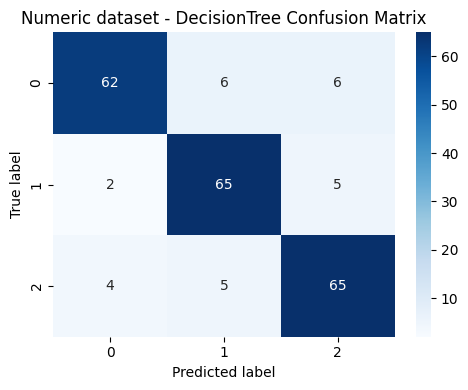


=== RandomForest (Numeric dataset) ===
Accuracy: 0.85
F1 (macro): 0.850159957625093

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84        74
           1       0.87      0.86      0.87        72
           2       0.79      0.91      0.84        74

    accuracy                           0.85       220
   macro avg       0.86      0.85      0.85       220
weighted avg       0.86      0.85      0.85       220



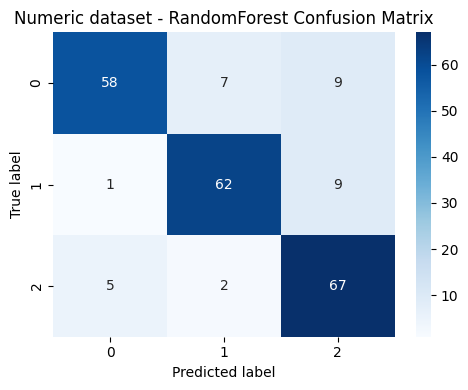

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_results = {}

for name, model in numeric_models.items():
    acc, f1, cm, y_pred, labels = evaluate_model(
        model, Xn_train, Xn_test, yn_train, yn_test
    )

    numeric_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "cm": cm,
        "labels": labels,
    }

    print(f"\n=== {name} (Numeric dataset) ===")
    print("Accuracy:", acc)
    print("F1 (macro):", f1)
    print("\nClassification report:")
    print(classification_report(yn_test, y_pred))

    #confusion matrix heatmap
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(f"Numeric dataset - {name} Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


=== LogisticRegression (Survey dataset) ===
Accuracy: 0.9822485207100592
F1 (macro): 0.9315584042072395

Classification report:
              precision    recall  f1-score   support

    Distress       0.75      1.00      0.86         6
    Eustress       1.00      0.98      0.99       154
    NoStress       0.90      1.00      0.95         9

    accuracy                           0.98       169
   macro avg       0.88      0.99      0.93       169
weighted avg       0.99      0.98      0.98       169



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


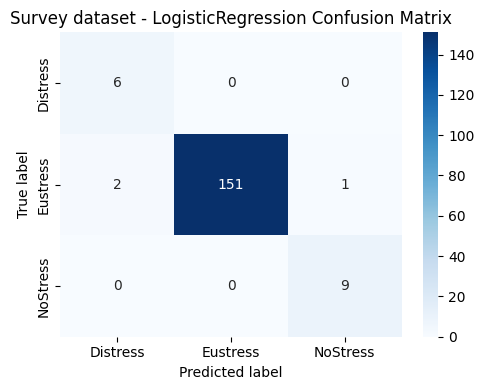


=== DecisionTree (Survey dataset) ===
Accuracy: 0.834319526627219
F1 (macro): 0.5453915453915453

Classification report:
              precision    recall  f1-score   support

    Distress       0.40      0.67      0.50         6
    Eustress       0.94      0.87      0.91       154
    NoStress       0.18      0.33      0.23         9

    accuracy                           0.83       169
   macro avg       0.51      0.62      0.55       169
weighted avg       0.88      0.83      0.86       169



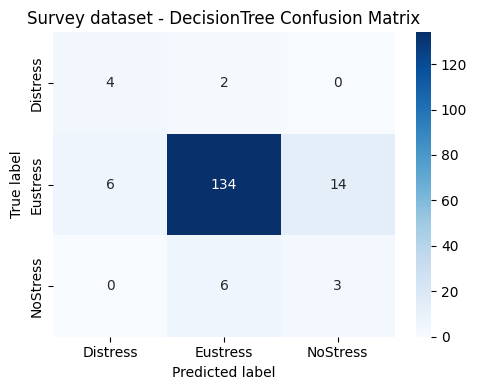


=== RandomForest (Survey dataset) ===
Accuracy: 0.9289940828402367
F1 (macro): 0.5372835497835498

Classification report:
              precision    recall  f1-score   support

    Distress       1.00      0.17      0.29         6
    Eustress       0.93      1.00      0.96       154
    NoStress       1.00      0.22      0.36         9

    accuracy                           0.93       169
   macro avg       0.98      0.46      0.54       169
weighted avg       0.93      0.93      0.91       169



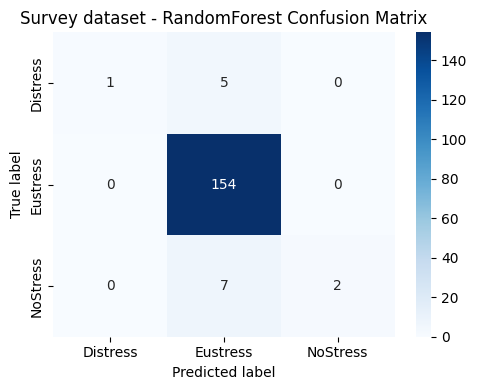

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

survey_results = {}

for name, model in survey_models.items():
    acc, f1, cm, y_pred, labels = evaluate_model(
        model, Xs_train, Xs_test, ys_train, ys_test
    )

    survey_results[name] = {
        "accuracy": acc,
        "f1": f1,
        "cm": cm,
        "labels": labels,
    }

    print(f"\n=== {name} (Survey dataset) ===")
    print("Accuracy:", acc)
    print("F1 (macro):", f1)
    print("\nClassification report:")
    print(classification_report(ys_test, y_pred))

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(f"Survey dataset - {name} Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

In [49]:
summary_rows = []

for name, res in numeric_results.items():
    summary_rows.append({
        "Dataset": "Numeric",
        "Model": name,
        "Accuracy": res["accuracy"],
        "F1_macro": res["f1"],
    })

for name, res in survey_results.items():
    summary_rows.append({
        "Dataset": "Survey",
        "Model": name,
        "Accuracy": res["accuracy"],
        "F1_macro": res["f1"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Dataset,Model,Accuracy,F1_macro
0,Numeric,LogisticRegression,0.854545,0.854870
1,Numeric,DecisionTree,0.872727,0.872761
2,Numeric,RandomForest,0.850000,0.850160
3,Survey,LogisticRegression,0.982249,0.931558
4,Survey,DecisionTree,0.834320,0.545392
5,Survey,RandomForest,0.928994,0.537284


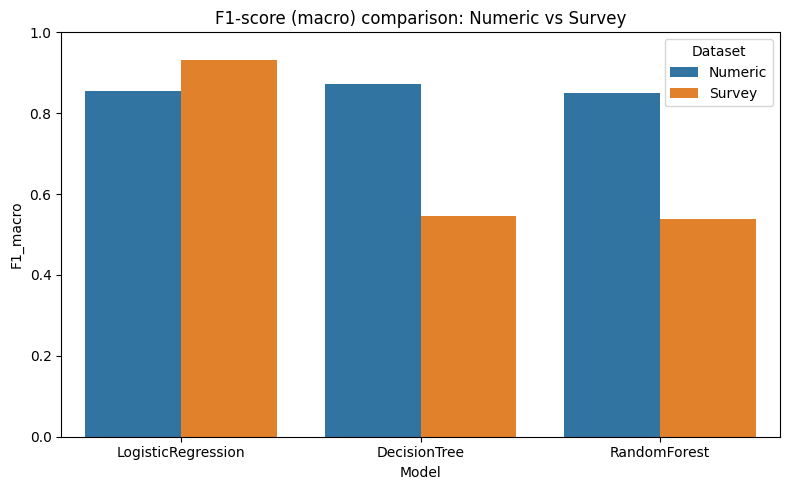

In [50]:
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x="Model", y="F1_macro", hue="Dataset")
plt.title("F1-score (macro) comparison: Numeric vs Survey")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

In [51]:
nlp_path = "/content/Combined Data.csv"
nlp_df = pd.read_csv(nlp_path)
print("NLP dataset shape:", nlp_df.shape)
nlp_df.head()

NLP dataset shape: (53043, 3)


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [52]:
#keep only relevant columns
nlp_df = nlp_df[["statement", "status"]].dropna()

print("Unique labels:", nlp_df["status"].unique())
print("\nLabel distribution (proportions):")
print(nlp_df["status"].value_counts(normalize=True))

display(nlp_df.head())

Unique labels: ['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']

Label distribution (proportions):
status
Normal                  0.310226
Depression              0.292401
Suicidal                0.202198
Anxiety                 0.072911
Bipolar                 0.052714
Stress                  0.049107
Personality disorder    0.020444
Name: proportion, dtype: float64


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [53]:
from sklearn.model_selection import train_test_split

X_text = nlp_df["statement"]
y_text = nlp_df["status"]

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_text,
)

print("Text train size:", Xt_train.shape[0])
print("Text test size: ", Xt_test.shape[0])

Text train size: 42144
Text test size:  10537


In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

text_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words="english",
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
    )),
])

In [55]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

#fit text model
text_model.fit(Xt_train, yt_train)

#predict on test set
yt_pred = text_model.predict(Xt_test)

#metrics
text_acc = accuracy_score(yt_test, yt_pred)
text_f1  = f1_score(yt_test, yt_pred, average="macro")
cm_text  = confusion_matrix(yt_test, yt_pred, labels=sorted(y_text.unique()))

print("=== NLP Text Model (TF-IDF + Logistic Regression) ===")
print("Accuracy:", text_acc)
print("F1 (macro):", text_f1)
print("\nClassification report:")
print(classification_report(yt_test, yt_pred))


=== NLP Text Model (TF-IDF + Logistic Regression) ===
Accuracy: 0.7510676663186865
F1 (macro): 0.7084431545799476

Classification report:
                      precision    recall  f1-score   support

             Anxiety       0.75      0.83      0.79       768
             Bipolar       0.76      0.77      0.77       556
          Depression       0.78      0.58      0.67      3081
              Normal       0.88      0.91      0.90      3269
Personality disorder       0.49      0.76      0.60       215
              Stress       0.48      0.65      0.55       517
            Suicidal       0.65      0.75      0.70      2131

            accuracy                           0.75     10537
           macro avg       0.69      0.75      0.71     10537
        weighted avg       0.76      0.75      0.75     10537



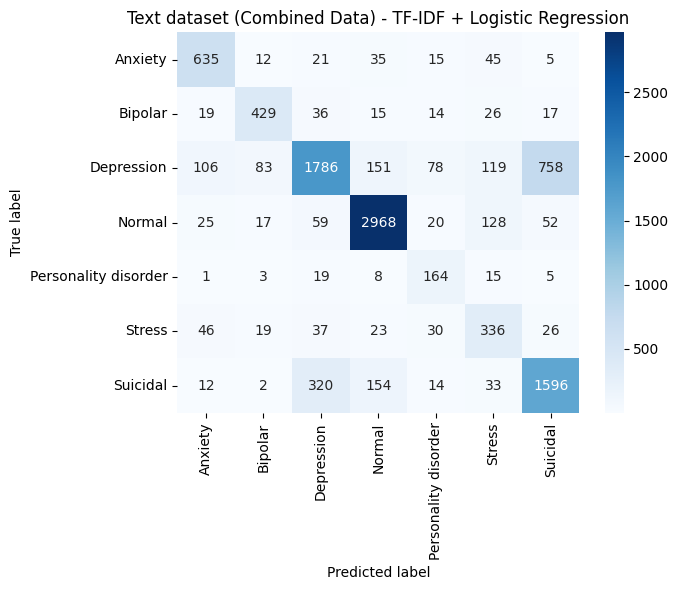

In [56]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_text,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_text.unique()),
    yticklabels=sorted(y_text.unique()),
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Text dataset (Combined Data) - TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

In [57]:
text_row = pd.DataFrame([{
    "Dataset": "Text (NLP)",
    "Model": "LogReg + TF-IDF",
    "Accuracy": text_acc,
    "F1_macro": text_f1,
}])

summary_df = pd.concat([summary_df, text_row], ignore_index=True)
summary_df

,Dataset,Model,Accuracy,F1_macro
0,Numeric,LogisticRegression,0.854545,0.854870
1,Numeric,DecisionTree,0.872727,0.872761
2,Numeric,RandomForest,0.850000,0.850160
3,Survey,LogisticRegression,0.982249,0.931558
4,Survey,DecisionTree,0.834320,0.545392
5,Survey,RandomForest,0.928994,0.537284
6,Text (NLP),LogReg + TF-IDF,0.751068,0.708443


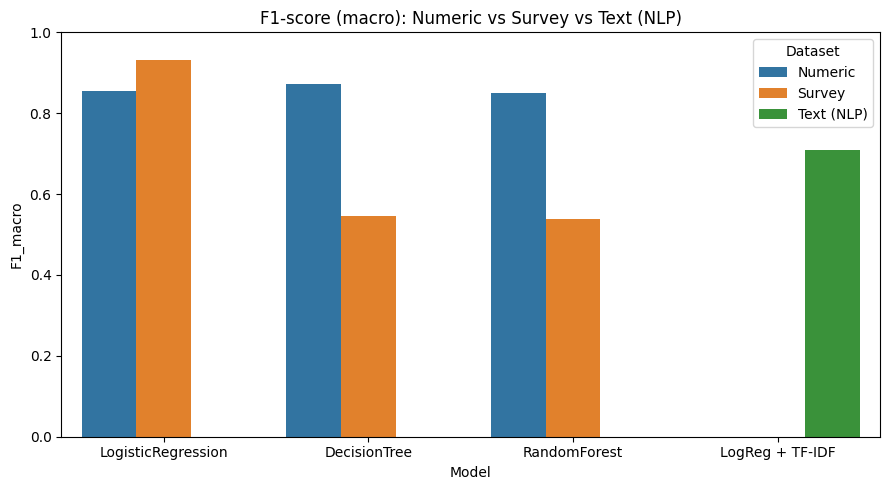

In [58]:
plt.figure(figsize=(9, 5))
sns.barplot(data=summary_df, x="Model", y="F1_macro", hue="Dataset")
plt.title("F1-score (macro): Numeric vs Survey vs Text (NLP)")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()